# Dealership Cross-Sell Propensity — Modeling

**Business question:** Sales can't call every customer. Who should they call first, and how much does that beat calling at random?

This notebook covers Phase 2 (preprocessing, logistic regression baseline, LightGBM). Later phases (decile/lift table, SHAP, export) are gated on LightGBM beating the baseline on ROC-AUC.

> Data: public Kaggle "Health Insurance Cross Sell Prediction" dataset, reframed as a dealership cross-sell case. Not real client or employer data.

**Metric note:** positive rate is ~12%, so accuracy is misleading and is not reported. ROC-AUC is the sanity check here; lift/deciles are the headline metric in the next phase.

## 1. Load data from Postgres
Reads the same `customers` table the SQL EDA (`sql/01_eda.sql`) ran on — not the raw CSV.

In [1]:
import os

import numpy as np
import pandas as pd
from dotenv import find_dotenv, load_dotenv
from sqlalchemy import create_engine

load_dotenv(find_dotenv(usecwd=True))
engine = create_engine(os.environ["DATABASE_URL"])
# Full pull takes ~15s. On this machine the transfer from Neon's pooler intermittently stalls
# (seen in plain scripts too, not a notebook issue) -- if this cell hangs past ~1 min, restart it.
# ORDER BY id: Postgres row order is otherwise arbitrary, which would silently change the
# random_state split (and every downstream number) between runs.
df = pd.concat(pd.read_sql("SELECT * FROM customers ORDER BY id", engine, chunksize=50_000), ignore_index=True)
df.shape

(381109, 12)

In [2]:
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42

In [3]:
# Data contract checks (IMPLEMENTATION_GUIDE section 3) — fail loudly if the table drifted
assert len(df) == 381_109, f"unexpected row count: {len(df)}"
assert df["id"].is_unique
assert set(df["response"].unique()) == {0, 1}

print(f"Rows: {len(df):,}")
print(f"Responders: {df['response'].sum():,}  ({df['response'].mean():.1%} positive rate)")
print("Missing values per column:")
print(df.isna().sum().to_string())
df.head()

Rows: 381,109
Responders: 46,710  (12.3% positive rate)
Missing values per column:
id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0


,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
for col in ["gender", "vehicle_age", "vehicle_damage", "previously_insured", "driving_license"]:
    print(df[col].value_counts().to_dict())

{'Male': 206089, 'Female': 175020}
{'1-2 Year': 200316, '< 1 Year': 164786, '> 2 Years': 16007}
{'Yes': 192413, 'No': 188696}
{0: 206481, 1: 174628}
{1: 380297, 0: 812}


## 2. Preprocessing (guide 4.1)

- `gender`, `vehicle_damage` → binary 0/1.
- `vehicle_age` → ordinal (`< 1 Year`=0, `1-2 Year`=1, `> 2 Years`=2); the categories are ordered and the EDA shows response rising with vehicle age.
- `region_code` and `policy_sales_channel` are stored as floats but are nominal IDs, so they are cast to int. LightGBM can split on the codes directly; for the logistic regression they are one-hot encoded (rare codes grouped), otherwise the baseline would treat "channel 152 > channel 26" as meaningful and be an unfairly weak floor.
- `id` is kept out of the feature matrix. It stays reachable through the DataFrame index (`df.loc[X_test.index, "id"]`) for the export step.
- 80/20 split, stratified on `response`.

In [5]:
VEHICLE_AGE_ORDER = {"< 1 Year": 0, "1-2 Year": 1, "> 2 Years": 2}

X = pd.DataFrame(index=df.index)
X["gender_male"] = (df["gender"] == "Male").astype(int)
X["age"] = df["age"]
X["driving_license"] = df["driving_license"]
X["region_code"] = df["region_code"].astype(int)
X["previously_insured"] = df["previously_insured"]
X["vehicle_age"] = df["vehicle_age"].map(VEHICLE_AGE_ORDER)
X["vehicle_damage"] = (df["vehicle_damage"] == "Yes").astype(int)
X["annual_premium"] = df["annual_premium"]
X["policy_sales_channel"] = df["policy_sales_channel"].astype(int)
X["vintage"] = df["vintage"]
y = df["response"]

assert X.notna().all().all(), "encoding produced NaNs — check category labels"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, positive rate {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, positive rate {y_test.mean():.2%}")

Train: (304887, 10), positive rate 12.26%
Test:  (76222, 10), positive rate 12.26%


## 3. Baseline — logistic regression (guide 4.2)

Class imbalance handled with `class_weight="balanced"` (each class weighted inversely to its frequency, so the ~12% responders count as much as the ~88% non-responders in the loss).

In [6]:
nominal_cols = ["region_code", "policy_sales_channel"]
numeric_cols = [c for c in X.columns if c not in nominal_cols]

baseline = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("nom", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=100), nominal_cols),
    ])),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
baseline.fit(X_train, y_train)

baseline_proba = baseline.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_proba)
print(f"Logistic regression ROC-AUC: {baseline_auc:.4f}")

Logistic regression ROC-AUC: 0.8498


## 4. LightGBM (guide 4.3)

Class imbalance handled with `is_unbalance=True` (LightGBM up-weights the positive class by the negative/positive ratio). Same train/test split as the baseline.

`min_child_weight=1` (minimum summed hessian per leaf; LightGBM's default is 0.001): previously insured customers respond at 0.1%, so near-pure leaves have hessians close to zero and the Newton step divides by almost nothing. With the default, 106 leaves came out with |value| > 5 (max 732), giving raw scores down to −742 log-odds and SHAP values of ±150 that are meaningless as effect sizes. With the constraint, leaves stay within ±2.1, SHAP within ±3.4, and test AUC is essentially unchanged (0.8566 → 0.8571). This is a sanity constraint, not tuning.

Side effect worth knowing for later phases: re-weighting inflates predicted probabilities above the true ~12% base rate. That's fine for ranking customers (AUC, deciles), but the `probability` column should be read as a score, not a calibrated likelihood.

In [7]:
model = LGBMClassifier(is_unbalance=True, n_estimators=300, min_child_weight=1,
                       random_state=RANDOM_STATE, verbose=-1)
model.fit(X_train, y_train)

lgbm_proba = model.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
print(f"LightGBM ROC-AUC: {lgbm_auc:.4f}")

LightGBM ROC-AUC: 0.8571


## 5. Confusion matrices (default 0.5 threshold)

Shown for completeness (guide 4.2). With class re-weighting, a 0.5 cut-off flags far more customers than the 12% who respond — in practice the business picks a cut-off by call capacity (decile), which the lift table in the next phase addresses.

In [8]:
def show_confusion(name, proba):
    cm = confusion_matrix(y_test, (proba >= 0.5).astype(int))
    tn, fp, fn, tp = cm.ravel()
    print(f"{name}")
    print(pd.DataFrame(cm, index=["actual 0", "actual 1"], columns=["pred 0", "pred 1"]).to_string())
    print(f"  recall (responders caught): {tp / (tp + fn):.1%}   precision: {tp / (tp + fp):.1%}   "
          f"flagged: {(tp + fp) / len(y_test):.1%} of customers\n")

show_confusion("Logistic regression", baseline_proba)
show_confusion("LightGBM", lgbm_proba)

Logistic regression
          pred 0  pred 1
actual 0   44237   22643
actual 1     589    8753
  recall (responders caught): 93.7%   precision: 27.9%   flagged: 41.2% of customers

LightGBM
          pred 0  pred 1
actual 0   45887   20993
actual 1     813    8529
  recall (responders caught): 91.3%   precision: 28.9%   flagged: 38.7% of customers



## 6. Gate: LightGBM must beat the baseline before SHAP / export

In [9]:
print(f"Logistic regression ROC-AUC: {baseline_auc:.4f}")
print(f"LightGBM ROC-AUC:            {lgbm_auc:.4f}")
print(f"Difference:                  {lgbm_auc - baseline_auc:+.4f}")

assert lgbm_auc > baseline_auc, (
    "LightGBM does not beat the baseline — check encoding and split before going further"
)
print("\nGate passed: LightGBM beats the logistic regression baseline.")

Logistic regression ROC-AUC: 0.8498
LightGBM ROC-AUC:            0.8571
Difference:                  +0.0074

Gate passed: LightGBM beats the logistic regression baseline.


## 7. Decile / lift table (guide 4.4)

The business view: rank every test-set customer by LightGBM score, cut into 10 equal-sized deciles (decile 9 = highest scores), and see how many of the actual responders each decile contains. At random, each decile would hold 10% of responders — a lift of 1.0×.

In [10]:
test_results = X_test.copy()
test_results["response"] = y_test.values
test_results["probability"] = model.predict_proba(X_test)[:, 1]
test_results["decile"] = pd.qcut(test_results["probability"], 10, labels=False, duplicates="drop")
assert test_results["decile"].nunique() == 10, "qcut dropped bins — probability ties collapsed a decile"

lift_table = (test_results.groupby("decile")
              .agg(customers=("response", "size"), responders=("response", "sum"))
              .sort_index(ascending=False))
lift_table["response_rate_pct"] = (100 * lift_table["responders"] / lift_table["customers"]).round(1)
lift_table["cumulative_responders_pct"] = (100 * lift_table["responders"].cumsum() / lift_table["responders"].sum()).round(1)

# Extra context columns: lift vs. the overall rate, and the cumulative view (top N deciles called)
overall_rate_pct = 100 * test_results["response"].mean()
cum_responders_share = lift_table["responders"].cumsum() / lift_table["responders"].sum()
cum_customers_share = lift_table["customers"].cumsum() / lift_table["customers"].sum()
lift_table["lift"] = (100 * lift_table["responders"] / lift_table["customers"] / overall_rate_pct).round(2)
lift_table["cumulative_customers_pct"] = (100 * cum_customers_share).round(1)
lift_table["cumulative_lift"] = (cum_responders_share / cum_customers_share).round(2)

print(f"Overall test-set response rate: {overall_rate_pct:.1f}%\n")
print(lift_table.to_string())

Overall test-set response rate: 12.3%



        customers  responders  response_rate_pct  cumulative_responders_pct  lift  cumulative_customers_pct  cumulative_lift
decile                                                                                                                      
9            7622        3004               39.4                       32.2  3.22                      10.0             3.22
8            7623        2415               31.7                       58.0  2.58                      20.0             2.90
7            7622        1965               25.8                       79.0  2.10                      30.0             2.63
6            7622        1270               16.7                       92.6  1.36                      40.0             2.32
5            7622         576                7.6                       98.8  0.62                      50.0             1.98
4            7622         100                1.3                       99.9  0.11                      60.0             1.66

In [11]:
top = lift_table.iloc[0]
top3 = lift_table.iloc[2]
print(f"Top decile: {int(top['responders']):,} of {int(lift_table['responders'].sum()):,} responders "
      f"({top['cumulative_responders_pct']:.1f}%) vs 10% at random -> {top['cumulative_lift']:.2f}x lift; "
      f"response rate {top['response_rate_pct']:.1f}% vs {overall_rate_pct:.1f}% overall.")
print(f"Top 3 deciles (30% of customers): {top3['cumulative_responders_pct']:.1f}% of responders "
      f"-> {top3['cumulative_lift']:.2f}x lift.")

Top decile: 3,004 of 9,342 responders (32.2%) vs 10% at random -> 3.22x lift; response rate 39.4% vs 12.3% overall.
Top 3 deciles (30% of customers): 79.0% of responders -> 2.63x lift.


**Headline:** the top decile (10% of customers) captures **32.2% of all responders vs 10% at random — a 3.22× lift** (39.4% response rate vs 12.3% overall). Calling the top 3 deciles (30% of customers) reaches 79.0% of responders (2.63× lift); the bottom 6 deciles together hold just 0.1% of responders.

## 8. SHAP explainability (guide 4.5)

SHAP values from LightGBM on the full test set, in log-odds units (positive = pushes towards responding). The top drivers are then checked against the SQL EDA findings recorded in PRD.md's "Known signals".

D:\PHyton\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


D:\PHyton\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


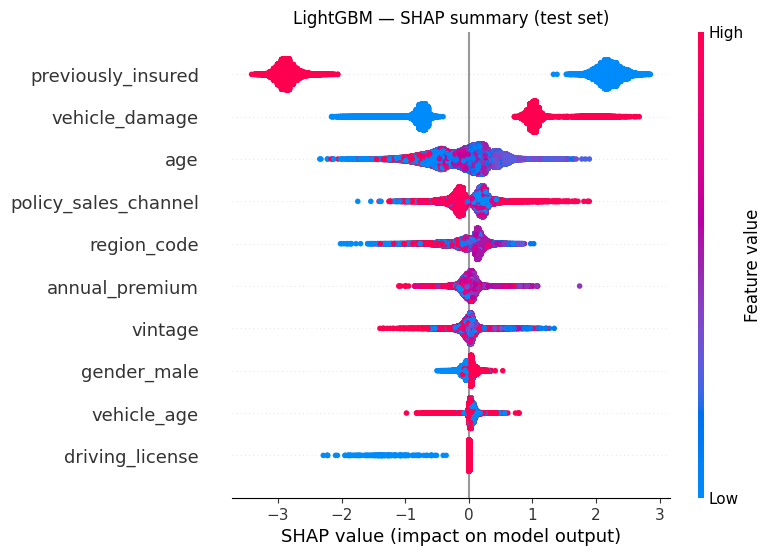

Saved D:\TUGAS\C Path\Portfolio\Data Science\dealership-crosssell-propensity\dealership-crosssell-propensity\notebooks\shap_summary.png


In [12]:
import shap
import matplotlib.pyplot as plt
from pathlib import Path

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):  # older shap versions return [class 0, class 1] for binary models
    shap_values = shap_values[1]
assert shap_values.shape == X_test.shape

shap.summary_plot(shap_values, X_test, show=False)
plt.title("LightGBM — SHAP summary (test set)")
SHAP_PLOT = Path(find_dotenv(usecwd=True)).parent / "notebooks" / "shap_summary.png"
plt.savefig(SHAP_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {SHAP_PLOT}")

In [13]:
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

importance = shap_df.abs().mean().sort_values(ascending=False)
print("Mean |SHAP| (global importance):")
print((importance.round(3)).to_string())

def mean_shap_by(feature, groups):
    return (pd.DataFrame({"group": groups, "mean_shap": shap_df[feature], "response": y_test})
              .groupby("group", observed=True)
              .agg(customers=("response", "size"), mean_shap=("mean_shap", "mean"),
                   test_response_rate_pct=("response", lambda r: round(100 * r.mean(), 1)))
              .round({"mean_shap": 3}))

age_band = pd.cut(X_test["age"], bins=[0, 29, 39, 49, 59, 200], labels=["20s", "30s", "40s", "50s", "60+"])
vehicle_age_label = X_test["vehicle_age"].map({v: k for k, v in VEHICLE_AGE_ORDER.items()})

print("\nDirection checks (mean SHAP per group, same groupings as sql/01_eda.sql):")
for feature, groups in [("previously_insured", X_test["previously_insured"]),
                        ("vehicle_damage", X_test["vehicle_damage"].map({1: "Yes", 0: "No"})),
                        ("vehicle_age", vehicle_age_label),
                        ("age", age_band)]:
    print(f"\n{feature}")
    print(mean_shap_by(feature, groups).to_string())

Mean |SHAP| (global importance):
previously_insured      2.510
vehicle_damage          0.941
age                     0.369
policy_sales_channel    0.221
region_code             0.191
annual_premium          0.085
vintage                 0.082
gender_male             0.068
vehicle_age             0.055
driving_license         0.006

Direction checks (mean SHAP per group, same groupings as sql/01_eda.sql):

previously_insured
       customers  mean_shap  test_response_rate_pct
group                                              
0          41271      2.209                    22.5
1          34951     -2.866                     0.1

vehicle_damage
       customers  mean_shap  test_response_rate_pct
group                                              
No         37768     -0.817                     0.5
Yes        38454      1.063                    23.8

vehicle_age
           customers  mean_shap  test_response_rate_pct
group                                                  
1-2 Year       

### 8.1 Investigating where SHAP and the SQL EDA differ

The raw SQL rates for vehicle age (`> 2 Years` 29.4% vs `< 1 Year` 4.4%) and age band (20s 4.1%) look much stronger than their SHAP contributions. Raw rates don't control for other features; SHAP does. Check how these features overlap with insurance status and damage, and what the rates look like inside the segment that actually responds (not previously insured + damaged).

In [14]:
eda = df.assign(
    age_band=pd.cut(df["age"], bins=[0, 29, 39, 49, 59, 200], labels=["20s", "30s", "40s", "50s", "60+"]),
    not_insured=1 - df["previously_insured"],
    damaged=(df["vehicle_damage"] == "Yes").astype(int),
)
core = eda[(eda["previously_insured"] == 0) & (eda["vehicle_damage"] == "Yes")]

print("Profile by vehicle_age (full table):")
print(eda.groupby("vehicle_age").agg(customers=("id", "size"), mean_age=("age", "mean"),
                                     pct_not_insured=("not_insured", "mean"), pct_damaged=("damaged", "mean"),
                                     response_rate=("response", "mean")).round(3).to_string())

print("\nResponse rate by vehicle_age inside the not-insured + damaged segment:")
print(core.groupby("vehicle_age")["response"].agg(customers="size", response_rate="mean").round(3).to_string())

print("\nProfile by age_band (full table):")
print(eda.groupby("age_band", observed=True).agg(customers=("id", "size"),
                                                 pct_vehicle_lt_1yr=("vehicle_age", lambda s: (s == "< 1 Year").mean()),
                                                 pct_not_insured=("not_insured", "mean"), pct_damaged=("damaged", "mean"),
                                                 response_rate=("response", "mean")).round(3).to_string())

print("\nResponse rate by age_band inside the not-insured + damaged segment:")
print(core.groupby("age_band", observed=True)["response"].agg(customers="size", response_rate="mean").round(3).to_string())

Profile by vehicle_age (full table):
             customers  mean_age  pct_not_insured  pct_damaged  response_rate
vehicle_age                                                                  
1-2 Year        200316    49.034            0.674        0.640          0.174
< 1 Year        164786    24.822            0.337        0.292          0.044
> 2 Years        16007    55.172            0.997        0.999          0.294

Response rate by vehicle_age inside the not-insured + damaged segment:
             customers  response_rate
vehicle_age                          
1-2 Year        122328          0.279
< 1 Year         44210          0.154
> 2 Years        15953          0.295

Profile by age_band (full table):
          customers  pct_vehicle_lt_1yr  pct_not_insured  pct_damaged  response_rate
age_band                                                                            
20s          155203               0.959            0.342        0.301          0.041
30s           54253  

**SHAP vs. SQL EDA (PRD "Known signals")**

Top 3 drivers by mean |SHAP|: `previously_insured` (2.51), `vehicle_damage` (0.94), `age` (0.37). Next is `policy_sales_channel` (0.22); everything else is below 0.2.

| Driver | SQL EDA | SHAP | Verdict |
|---|---|---|---|
| `previously_insured` | not insured 22.5% vs insured 0.1% | #1. Mean SHAP +2.21 when 0, −2.87 when 1 | **Agrees** (rank and direction) |
| `vehicle_damage` | damaged 23.8% vs not damaged 0.5% | #2. Mean SHAP +1.06 for Yes, −0.82 for No | **Agrees** (rank and direction) |
| `age` | non-linear: 20s 4.1%, peak 40s 21.2%, 60+ 10.0% | #3. Non-linear: 60+ −0.65, 20s −0.29, peak in 30s +0.48, 40s +0.23 | **Partly agrees**: same hump shape, but the peak is the 30s, not the 40s, and 60+ (not 20s) is the most negative |

**Disagreement: vehicle age.** The EDA listed it as a strong signal (`> 2 Years` 29.4% vs `< 1 Year` 4.4%), but SHAP ranks it 9th of 10 (0.055), with group means all within ±0.11. `> 2 Years` is highest (+0.10), as expected, but `< 1 Year` (+0.06) sits above `1-2 Year` (+0.03).

**Why (section 8.1 output above).** Vehicle age and age mostly repeat information already carried by insurance status and damage, and they overlap with each other:
- `> 2 Years` owners are 99.7% not insured and 99.9% damaged. Inside the not-insured + damaged segment, `> 2 Years` responds at 29.5% vs 27.9% for `1-2 Year`, so almost the whole raw gap disappears once insurance and damage are accounted for.
- `< 1 Year` is effectively the young-customer flag: 95.9% of customers in their 20s drive a `< 1 Year` vehicle. Inside the segment, `< 1 Year` (15.4%) and the 20s (14.0%) respond at nearly the same rate. The model credits that effect to `age`, leaving little for `vehicle_age`.
- The 20s' very low raw rate (4.1%) is mostly because only 34% of them are uninsured and 30% have damage. Inside the segment they still respond least (14.0%), but close to 60+ (17.1%), which is why SHAP puts both ends of the age range below zero. The segment's peak is the 30s (34.9% vs 31.4% for the 40s), matching SHAP's 30s peak.

**Conclusion:** the model's top two drivers confirm the SQL findings. The vehicle-age and age differences come from raw rates double-counting overlapping features, not from the model contradicting the data. For targeting, vehicle age adds almost nothing once insurance status, damage and age are known.

## 9. Export for Power BI (guide 4.6)

`dashboard/customer_scores.csv` is the only handoff to Power BI: one row per **test-set** customer (the 20% the model never saw in training, so the scores are honest out-of-sample), with key attributes, the actual `response`, the LightGBM `probability` and its `decile` (9 = highest scores, same cut as the lift table above). As noted in section 4, `probability` is a ranking score inflated by `is_unbalance`, not a calibrated likelihood.

In [15]:
PROJECT_ROOT = Path(find_dotenv(usecwd=True)).parent
EXPORT_PATH = PROJECT_ROOT / "dashboard" / "customer_scores.csv"

export = df.loc[X_test.index, ["id", "age", "vehicle_age", "vehicle_damage", "previously_insured", "annual_premium"]].copy()
export["response"] = y_test.values
export["probability"] = model.predict_proba(X_test)[:, 1]
export["decile"] = pd.qcut(export["probability"], 10, labels=False, duplicates="drop")

# Same probabilities and cut as the lift table, so the dashboard's deciles match the notebook's
assert export["decile"].equals(test_results["decile"])

export.to_csv(EXPORT_PATH, index=False)
print(f"Wrote {len(export):,} rows to {EXPORT_PATH}")

Wrote 76,222 rows to D:\TUGAS\C Path\Portfolio\Data Science\dealership-crosssell-propensity\dealership-crosssell-propensity\dashboard\customer_scores.csv


In [16]:
# Verification checkpoint (guide section 6), run against the file on disk rather than the in-memory frame
scores = pd.read_csv(EXPORT_PATH)

assert len(scores) == len(X_test), f"row count {len(scores):,} != test set {len(X_test):,}"
assert scores["id"].is_unique
assert set(scores["id"]) == set(df.loc[X_test.index, "id"])
assert scores.notna().all().all()
assert scores["probability"].between(0, 1).all()
assert sorted(scores["decile"].unique()) == list(range(10))

by_decile = (scores.groupby("decile")
             .agg(customers=("id", "size"), min_probability=("probability", "min"),
                  max_probability=("probability", "max"), mean_probability=("probability", "mean"),
                  responders=("response", "sum"))
             .sort_index(ascending=False))
print(by_decile.round(4).to_string())

# Deciles must not overlap: every customer in decile d scores at least as high as everyone in decile d-1
assert (by_decile["min_probability"].values[:-1] >= by_decile["max_probability"].values[1:]).all()
top = scores.loc[scores["probability"].idxmax()]
assert top["decile"] == 9 and by_decile["mean_probability"].idxmax() == 9

print(f"\nRow count {len(scores):,} == test set {len(X_test):,}")
print(f"Decile 9 holds the highest scores: min {by_decile.loc[9, 'min_probability']:.4f} "
      f">= decile 8 max {by_decile.loc[8, 'max_probability']:.4f}; top-scored customer id {int(top['id'])} is in decile 9")
print("\nSpot check, 5 highest-scored customers:")
print(scores.nlargest(5, "probability").to_string(index=False))

        customers  min_probability  max_probability  mean_probability  responders
decile                                                                           
9            7622           0.7903           0.9310            0.8220        3004
8            7623           0.7380           0.7903            0.7644        2415
7            7622           0.6460           0.7379            0.6971        1965
6            7622           0.4686           0.6460            0.5683        1270
5            7622           0.1742           0.4686            0.3252         576
4            7622           0.0051           0.1742            0.0581         100
3            7622           0.0025           0.0051            0.0033           3
2            7622           0.0016           0.0025            0.0020           4
1            7622           0.0011           0.0016            0.0014           0
0            7623           0.0000           0.0011            0.0008           5

Row count 76,22